# Week 2 — Improve and compare forecasting models

**Flow:** Week 1 data → features → Moving Average baseline → Holt-Winters → XGBoost → Croston (only if needed) → MAE / WAPE / Bias → ensemble → agent recommends → human approves → save outputs

**Rules this notebook follows**
- Same products and same train / validation / test split as Week 1. No re-cleaning here.
- Train = fit, validation = choose settings, test = final score only. Nothing is tuned on test.
- Every model forecasts **one week ahead**, using actuals up to last week. That is how the Week 1 moving average works, so the comparison is fair.
- Error = forecast − actual. **Positive bias = over-forecasting**, negative = under-forecasting. The sign never changes in this notebook.

**Needs:** `pip install xgboost statsmodels` (pandas, numpy, matplotlib are already installed)

In [1]:
import itertools
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBRegressor

try:
    from IPython.display import display
except ImportError:  # running as a plain script
    display = print

warnings.filterwarnings("ignore")  # statsmodels convergence chatter on short windows
pd.set_option("display.width", 140)

# ---- paths (notebook sits next to the processed/ and outputs/ folders) ----
DATA_PATH = Path("processed/weekly_sales.csv")
W1_SUMMARY = Path("outputs/week1_summary.csv")
W1_BASELINE = Path("outputs/forecasts/baseline_forecast.csv")
OUT_DIR = Path("outputs")
CHART_DIR = OUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)
for _p in (DATA_PATH, W1_SUMMARY, W1_BASELINE):
    assert _p.exists(), f"{_p} not found. The notebook is running from {Path.cwd()}"

# ---- settings you may want to change ----
PARTIAL_WEEKS = ["2024-01-07"]   # weeks with incomplete data (see section 2)
SELECTION_WINDOW = "validation"  # window used to CHOOSE the model per product. Must be a window the
                                  # model has not already been scored on, or the pick is fit to the test data.
REPORT_WINDOW = "test_clean"     # window used ONLY to report the held-out accuracy of whatever
                                  # SELECTION_WINDOW picked. Never used to choose between models.
BIAS_LIMIT_PCT = 5.0             # |% bias| above this counts as a problem
WAPE_TOLERANCE_PT = 1.0          # if the best model is biased, accept a less-biased one within this many WAPE points
MIN_GAIN_OVER_BASELINE_PT = 0.5  # don't switch away from the Moving Average for less than this WAPE gain
INTERMITTENT_ZERO_PCT = 30.0     # products with at least this % zero-demand weeks get Croston

HW_CANDIDATES = {                # small on purpose: see section 5 for why there is no seasonal option
    "SES (no trend)": dict(trend=None),
    "Holt (additive trend)": dict(trend="add"),
    "Holt (damped trend)": dict(trend="add", damped_trend=True),
}
XGB_GRID = {"max_depth": [3, 5], "learning_rate": [0.05, 0.1], "n_estimators": [100, 200]}
ENSEMBLE_WEIGHTS = [0.7, 0.6, 0.5, 0.4, 0.3]   # weight on the first model of each pair; the second gets the rest
MIN_ENSEMBLE_GAIN_PT = 0.2      # an ensemble must beat the best single model on validation by at least this many WAPE points

## 1. Load the Week 1 data and the same products

In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
w1 = pd.read_csv(W1_SUMMARY)
SELECTED = w1["product_id"].tolist()          # same products Week 1 used

required = ["date", "product_id", "quantity_sold", "promotion_flag", "split"]
missing = [c for c in required if c not in raw.columns]
assert not missing, f"Week 1 file is missing columns: {missing}"

df = (
    raw[raw["product_id"].isin(SELECTED)]
    .sort_values(["product_id", "date"])
    .reset_index(drop=True)
)
OPTIONAL = [c for c in ["price", "discount_pct"] if c in df.columns]
print("Products:", SELECTED)
print("Optional columns found:", OPTIONAL or "none (price/discount not in Week 1 file)")
df.groupby("split").agg(first_week=("date", "min"), last_week=("date", "max"), rows=("date", "size"))

Products: ['P0016', 'P0020', 'P0014']
Optional columns found: none (price/discount not in Week 1 file)


,first_week,last_week,rows
split,,,
test,2023-09-24,2024-01-07,48
train,2022-01-02,2023-05-28,222
validation,2023-06-04,2023-09-17,48


## 2. Data check: is the last week incomplete?
Week 1 showed a collapse in the final week. If it hits *every* product it is almost certainly incomplete data, not real demand.

In [3]:
weekly_avg = raw.groupby("date")["quantity_sold"].mean()
low_weeks = weekly_avg[weekly_avg < 0.5 * weekly_avg.median()]
eval_dates = set(raw.loc[raw["split"].isin(["validation", "test"]), "date"])
low_eval = [d for d in low_weeks.index if d in eval_dates]
low_train = [d for d in low_weeks.index if d not in eval_dates]

print("Low weeks inside validation/test (all-product average under half the normal level):")
print(low_weeks[low_eval].round(0).to_string() if low_eval else "none")
if low_train:
    print("\nAlso low, but inside TRAIN (left as-is because Week 1 froze the data):",
          [d.strftime("%Y-%m-%d") for d in low_train])
print("\nPARTIAL_WEEKS in use:", PARTIAL_WEEKS)
if {d.strftime("%Y-%m-%d") for d in low_eval} != set(PARTIAL_WEEKS):
    print("WARNING: PARTIAL_WEEKS does not match the low weeks found in validation/test. Check the setting above.")

Low weeks inside validation/test (all-product average under half the normal level):
date
2024-01-07    662.0

Also low, but inside TRAIN (left as-is because Week 1 froze the data): ['2022-01-02']

PARTIAL_WEEKS in use: ['2024-01-07']


## 3. Week 2 features
Every lag / rolling feature uses `.shift(1)` so a week's own demand never leaks into its own forecast.

In [4]:
TARGET = "quantity_sold"
g = df.groupby("product_id")[TARGET]

df["month"] = df["date"].dt.month
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter
df["lag_1"] = g.shift(1)
df["lag_2"] = g.shift(2)
df["lag_4"] = g.shift(4)
df["rolling_mean_4"] = g.transform(lambda x: x.shift(1).rolling(4).mean())
df["rolling_mean_8"] = g.transform(lambda x: x.shift(1).rolling(8).mean())

FEATURES = ["lag_1", "lag_2", "lag_4", "rolling_mean_4", "month", "week_of_year", "promotion_flag"] + OPTIONAL
print("XGBoost features:", FEATURES)
if df["promotion_flag"].nunique() == 1:
    print("Note: promotion_flag is constant in this data, so XGBoost cannot learn anything from it yet.")

XGBoost features: ['lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'month', 'week_of_year', 'promotion_flag']
Note: promotion_flag is constant in this data, so XGBoost cannot learn anything from it yet.


## 4. Moving Average baseline (same as Week 1) + metrics with Bias

In [5]:
def metrics(actual, pred):
    """Error = forecast - actual. Positive bias = over-forecasting."""
    actual = np.asarray(actual, dtype=float)
    err = np.asarray(pred, dtype=float) - actual
    return {
        "mae": np.abs(err).mean(),
        "wape": 100 * np.abs(err).sum() / actual.sum(),
        "bias": err.mean(),                       # units per week
        "bias_pct": 100 * err.sum() / actual.sum(),
    }


df["moving_average"] = df["rolling_mean_4"]   # 4-week MA of the previous 4 weeks, exactly as in Week 1

# Reproduce Week 1: same forecasts, same MAE / WAPE
w1_base = pd.read_csv(W1_BASELINE, parse_dates=["date"])[["date", "product_id", "forecast_ma4"]]
chk = df.merge(w1_base, on=["date", "product_id"], how="left")
assert np.allclose(chk["moving_average"].fillna(-1), chk["forecast_ma4"].fillna(-1)), "MA forecasts differ from Week 1"

rows = []
for pid, s in df[df["split"] == "test"].groupby("product_id"):
    m = metrics(s[TARGET], s["moving_average"])
    ref = w1.set_index("product_id").loc[pid]
    assert abs(m["mae"] - ref["mae"]) < 0.01 and abs(m["wape"] - ref["wape"]) < 0.01, f"{pid}: differs from Week 1 summary"
    rows.append({"product_id": pid, **m})
print("Baseline reproduces Week 1 (forecasts, MAE and WAPE match). Bias added:")
pd.DataFrame(rows).round(2)

Baseline reproduces Week 1 (forecasts, MAE and WAPE match). Bias added:


,product_id,mae,wape,bias,bias_pct
0,P0014,707.27,15.33,267.30,5.79
1,P0016,999.30,21.89,364.27,7.98
2,P0020,841.25,17.81,197.78,4.19


## 5. Holt-Winters
Fitted per product, choosing the setting on **validation**. Each week is forecast one step ahead after refitting on everything before it.

**No seasonal option:** a 52-week season needs at least two full years in the training window. Train has about 74 weeks, so a seasonal model would be guessing. If the data grows, add `dict(trend="add", seasonal="add", seasonal_periods=52)` to `HW_CANDIDATES`.

In [6]:
def hw_one_step(values, start, stop, **cfg):
    """One-step-ahead forecasts for positions start..stop-1, refitting on all earlier weeks each time."""
    out = []
    for t in range(start, stop):
        fit = ExponentialSmoothing(values[:t], **cfg).fit()
        out.append(float(np.asarray(fit.forecast(1))[0]))
    return np.array(out)


ORDER = {"train": 0, "validation": 1, "test": 2}
df["holt_winters"] = np.nan
hw_rows, positions = [], {}

for pid, gp in df.groupby("product_id"):
    gp = gp.sort_values("date")
    assert gp["split"].map(ORDER).is_monotonic_increasing, f"{pid}: splits are not in time order"
    y = gp[TARGET].to_numpy(float)
    val_pos = np.flatnonzero(gp["split"] == "validation")
    test_pos = np.flatnonzero(gp["split"] == "test")
    positions[pid] = (gp.index, val_pos[0], val_pos[-1] + 1, test_pos[-1] + 1)
    for name, cfg in HW_CANDIDATES.items():
        p = hw_one_step(y, val_pos[0], val_pos[-1] + 1, **cfg)
        hw_rows.append({"product_id": pid, "config": name, **metrics(y[val_pos], p)})

hw_val = pd.DataFrame(hw_rows)
best_hw = hw_val.loc[hw_val.groupby("product_id")["wape"].idxmin()].set_index("product_id")["config"]
print("Holt-Winters settings on VALIDATION (lowest WAPE per product wins):")
display(hw_val.round(2))
print("Locked settings:", best_hw.to_dict())

# Lock the chosen setting, then forecast validation + test weeks one step ahead
for pid, (idx, v0, _, t1) in positions.items():
    y = df.loc[idx, TARGET].to_numpy(float)
    df.loc[idx[v0:t1], "holt_winters"] = hw_one_step(y, v0, t1, **HW_CANDIDATES[best_hw[pid]])

Holt-Winters settings on VALIDATION (lowest WAPE per product wins):


,product_id,config,mae,wape,bias,bias_pct
0,P0014,SES (no trend),510.66,10.54,-37.33,-0.77
1,P0014,Holt (additive trend),516.97,10.67,-5.28,-0.11
2,P0014,Holt (damped trend),523.33,10.80,35.47,0.73
3,P0016,SES (no trend),528.05,10.66,-99.56,-2.01
4,P0016,Holt (additive trend),510.32,10.30,-8.19,-0.17
5,P0016,Holt (damped trend),480.65,9.70,-24.42,-0.49
6,P0020,SES (no trend),499.99,10.74,168.42,3.62
7,P0020,Holt (additive trend),527.03,11.32,151.72,3.26
8,P0020,Holt (damped trend),534.63,11.48,257.57,5.53


Locked settings: {'P0014': 'SES (no trend)', 'P0016': 'Holt (damped trend)', 'P0020': 'SES (no trend)'}


## 6. XGBoost
One model trained on all selected products (three short series are too little data each). Small grid, chosen on **validation**.
For the test period the locked settings are refit on train + validation, and lag features use last week's actual.

In [7]:
df["xgboost"] = np.nan
train_df = df[df["split"] == "train"].dropna(subset=FEATURES)
val_df = df[df["split"] == "validation"]
test_df = df[df["split"] == "test"]
assert not val_df[FEATURES].isna().any().any() and not test_df[FEATURES].isna().any().any()

grid_rows = []
for depth, lr, n in itertools.product(XGB_GRID["max_depth"], XGB_GRID["learning_rate"], XGB_GRID["n_estimators"]):
    model = XGBRegressor(n_estimators=n, max_depth=depth, learning_rate=lr, random_state=42)
    model.fit(train_df[FEATURES], train_df[TARGET])
    grid_rows.append({"max_depth": depth, "learning_rate": lr, "n_estimators": n,
                      **metrics(val_df[TARGET], model.predict(val_df[FEATURES]))})
xgb_val = pd.DataFrame(grid_rows).sort_values("wape").reset_index(drop=True)
print("XGBoost grid on VALIDATION (best first):")
display(xgb_val.round(2))

best = xgb_val.iloc[0]
BEST_XGB = dict(max_depth=int(best["max_depth"]), learning_rate=float(best["learning_rate"]),
                n_estimators=int(best["n_estimators"]), random_state=42)
print("Locked settings:", BEST_XGB)

# validation forecasts: trained on train only
m_val = XGBRegressor(**BEST_XGB).fit(train_df[FEATURES], train_df[TARGET])
df.loc[val_df.index, "xgboost"] = m_val.predict(val_df[FEATURES])

# test forecasts: refit on train + validation with the same locked settings
fit_df = pd.concat([train_df, val_df])
m_test = XGBRegressor(**BEST_XGB).fit(fit_df[FEATURES], fit_df[TARGET])
df.loc[test_df.index, "xgboost"] = m_test.predict(test_df[FEATURES])

XGBoost grid on VALIDATION (best first):


,max_depth,learning_rate,n_estimators,mae,wape,bias,bias_pct
0,3,0.05,100,539.15,11.19,78.55,1.63
1,3,0.10,100,543.46,11.28,89.13,1.85
2,3,0.05,200,558.06,11.58,91.43,1.90
3,5,0.05,100,565.00,11.72,154.67,3.21
4,5,0.10,100,572.50,11.88,185.56,3.85
5,3,0.10,200,583.29,12.10,108.42,2.25
6,5,0.10,200,584.60,12.13,195.18,4.05
7,5,0.05,200,589.29,12.23,173.33,3.60


Locked settings: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 100, 'random_state': 42}


## 7. Is Croston needed?
Only for products whose Week 1 zero-demand share is high. It is not forced on every product.

In [8]:
def croston_one_step(values, start, stop, alpha=0.1):
    """Classic Croston, one step ahead: forecast = smoothed demand size / smoothed gap between demands."""
    out = []
    for t in range(start, stop):
        hist = values[:t]
        nz = np.flatnonzero(hist > 0)
        if len(nz) == 0:
            out.append(0.0)
            continue
        z, p, q = hist[nz[0]], nz[0] + 1.0, 1
        for x in hist[nz[0] + 1:]:
            if x > 0:
                z = alpha * x + (1 - alpha) * z
                p = alpha * q + (1 - alpha) * p
                q = 1
            else:
                q += 1
        out.append(z / p)
    return np.array(out)


ZERO_PCT = w1.set_index("product_id")["zero_demand_pct"]
INTERMITTENT = ZERO_PCT[ZERO_PCT >= INTERMITTENT_ZERO_PCT].index.tolist()
print("Zero-demand % from Week 1:", ZERO_PCT.to_dict())
print("Croston needed for:", INTERMITTENT or "no products (all demand is continuous)")

df["croston"] = np.nan
for pid in INTERMITTENT:
    idx, v0, _, t1 = positions[pid]
    y = df.loc[idx, TARGET].to_numpy(float)
    df.loc[idx[v0:t1], "croston"] = croston_one_step(y, v0, t1)

Zero-demand % from Week 1: {'P0016': 0.0, 'P0020': 0.0, 'P0014': 0.0}
Croston needed for: no products (all demand is continuous)


## 8. Ensemble: find the best pair of models
Every pair of models (Moving Average, Holt-Winters, XGBoost) is blended at several weights. The weights and the winning pair are chosen on **validation** only.
The ensemble is kept only if it beats the best single model by at least `MIN_ENSEMBLE_GAIN_PT` WAPE points. Croston is left out because it only exists for some products.

Why blending can help: two models make different mistakes, and averaging cancels part of them. It also cancels bias when one model runs high and the other runs low.

In [9]:
BASE_MODELS = {"Moving Average": "moving_average", "Holt-Winters": "holt_winters", "XGBoost": "xgboost"}
val_eval = df[df["split"] == "validation"]

single_val = {name: metrics(val_eval[TARGET], val_eval[col])["wape"] for name, col in BASE_MODELS.items()}
best_single_name = min(single_val, key=single_val.get)
best_single = single_val[best_single_name]
print("Single models on VALIDATION (WAPE %):", {k: round(v, 2) for k, v in single_val.items()})

ens_rows = []
for (a, col_a), (b, col_b) in itertools.combinations(BASE_MODELS.items(), 2):
    for w in ENSEMBLE_WEIGHTS:
        blend = w * val_eval[col_a] + (1 - w) * val_eval[col_b]
        ens_rows.append({"model_a": a, "model_b": b, "weight_a": w, "weight_b": round(1 - w, 1),
                         **metrics(val_eval[TARGET], blend)})
ens_val = pd.DataFrame(ens_rows).sort_values("wape").reset_index(drop=True)

print("\nBest weighting for each pair (validation):")
display(ens_val.drop_duplicates(["model_a", "model_b"]).round(2))

best_ens = ens_val.iloc[0]
ENSEMBLE_LABEL = f"Ensemble ({best_ens['model_a']} + {best_ens['model_b']})"
ens_cols = (BASE_MODELS[best_ens["model_a"]], BASE_MODELS[best_ens["model_b"]])
df["ensemble"] = best_ens["weight_a"] * df[ens_cols[0]] + best_ens["weight_b"] * df[ens_cols[1]]

gain = best_single - best_ens["wape"]
ENSEMBLE_KEPT = bool(gain >= MIN_ENSEMBLE_GAIN_PT)
print(f"\nBest pair: {best_ens['model_a']} {best_ens['weight_a']:.0%} + {best_ens['model_b']} {best_ens['weight_b']:.0%}"
      f"  ->  validation WAPE {best_ens['wape']:.2f}%")
print(f"Best single model: {best_single_name}  ->  validation WAPE {best_single:.2f}%  (ensemble gain {gain:+.2f} pts)")
print(f"{ENSEMBLE_LABEL} KEPT" if ENSEMBLE_KEPT else
      f"Ensemble DROPPED: gain is under {MIN_ENSEMBLE_GAIN_PT} pts, so it is not clearly better than {best_single_name}")

Single models on VALIDATION (WAPE %): {'Moving Average': np.float64(11.49), 'Holt-Winters': np.float64(10.31), 'XGBoost': np.float64(11.19)}

Best weighting for each pair (validation):


,model_a,model_b,weight_a,weight_b,mae,wape,bias,bias_pct
0,Moving Average,Holt-Winters,0.3,0.7,501.34,10.40,1.96,0.04
1,Holt-Winters,XGBoost,0.7,0.3,505.10,10.48,48.45,1.01
8,Moving Average,XGBoost,0.5,0.5,520.92,10.81,1.07,0.02



Best pair: Moving Average 30% + Holt-Winters 70%  ->  validation WAPE 10.40%
Best single model: Holt-Winters  ->  validation WAPE 10.31%  (ensemble gain -0.09 pts)
Ensemble DROPPED: gain is under 0.2 pts, so it is not clearly better than Holt-Winters


## 9. Evaluate every model on the same weeks
Three windows: `validation`, `test` (the same 16 weeks Week 1 used) and `test_clean` (test minus the incomplete week).

In [10]:
MODELS = {"Moving Average": "moving_average", "Holt-Winters": "holt_winters", "XGBoost": "xgboost"}
if ENSEMBLE_KEPT:
    MODELS[ENSEMBLE_LABEL] = "ensemble"
if INTERMITTENT:
    MODELS["Croston"] = "croston"

eval_df = df[df["split"].isin(["validation", "test"])].copy()
eval_df["is_partial_week"] = eval_df["date"].isin(pd.to_datetime(PARTIAL_WEEKS))
windows = {
    "validation": eval_df["split"] == "validation",
    "test": eval_df["split"] == "test",
    "test_clean": (eval_df["split"] == "test") & ~eval_df["is_partial_week"],
}

rows = []
for pid in SELECTED + ["ALL"]:
    sub = eval_df if pid == "ALL" else eval_df[eval_df["product_id"] == pid]
    for wname, wmask in windows.items():
        s = sub[wmask.loc[sub.index]]
        for mname, col in MODELS.items():
            if s.empty or s[col].isna().any():
                continue   # model was not run for this product (e.g. Croston)
            rows.append({"product_id": pid, "model": mname, "split": wname, "n_weeks": len(s),
                         **metrics(s[TARGET], s[col])})
metrics_df = pd.DataFrame(rows).round(3)


def show(split, pid="ALL"):
    t = metrics_df.query("product_id == @pid and split == @split")
    return t[["model", "mae", "wape", "bias", "bias_pct"]].set_index("model")


print("ALL PRODUCTS, TEST (same 16 weeks as Week 1, includes the incomplete week):")
display(show("test"))
print("ALL PRODUCTS, TEST_CLEAN (incomplete week removed):")
display(show("test_clean"))

ALL PRODUCTS, TEST (same 16 weeks as Week 1, includes the incomplete week):


,mae,wape,bias,bias_pct
model,,,,
Moving Average,849.271,18.328,276.448,5.966
Holt-Winters,705.409,15.224,217.914,4.703
XGBoost,715.683,15.445,303.454,6.549


ALL PRODUCTS, TEST_CLEAN (incomplete week removed):


,mae,wape,bias,bias_pct
model,,,,
Moving Average,620.650,12.686,9.639,0.197
Holt-Winters,478.575,9.782,-41.419,-0.847
XGBoost,474.583,9.700,34.872,0.713


## 10. Charts: one comparison chart per product

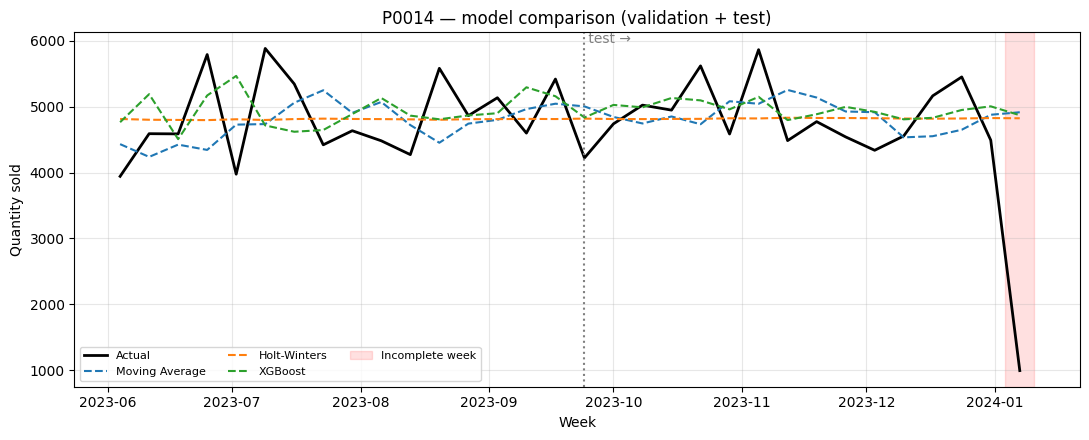

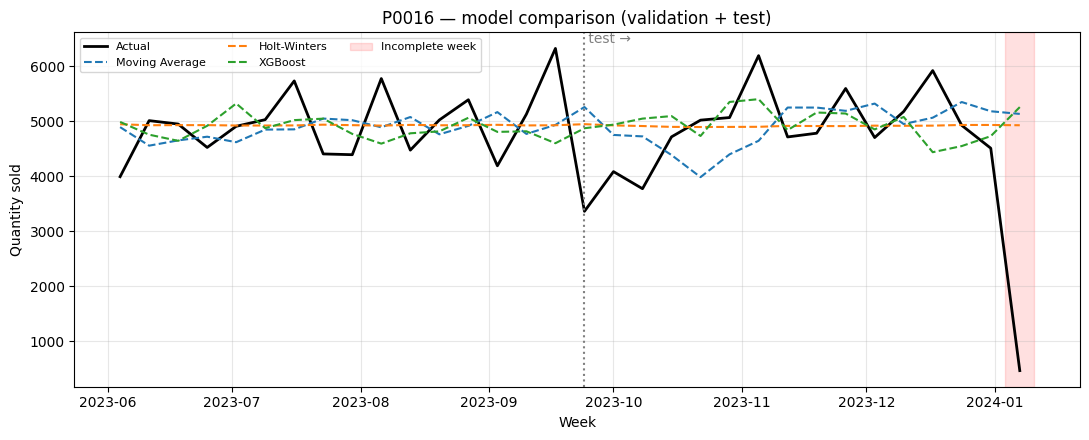

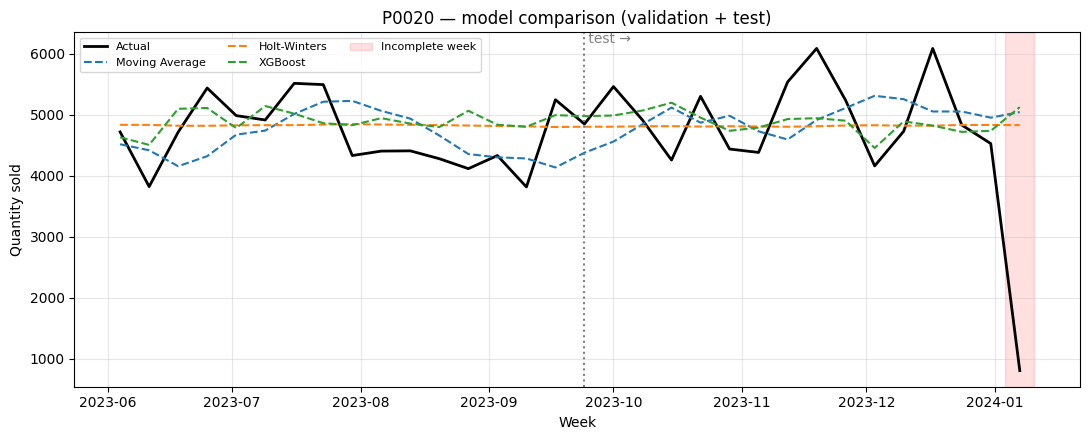

In [11]:
partial_dates = pd.to_datetime(PARTIAL_WEEKS)
test_start = eval_df.loc[eval_df["split"] == "test", "date"].min()

for pid, gp in eval_df.groupby("product_id"):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(gp["date"], gp[TARGET], color="black", lw=2, label="Actual")
    for mname, col in MODELS.items():
        if gp[col].notna().all():
            ax.plot(gp["date"], gp[col], lw=1.5, ls="--", label=mname)
    ax.axvline(test_start, color="grey", ls=":")
    ax.text(test_start, ax.get_ylim()[1], " test →", va="top", color="grey")
    for d in partial_dates:
        if d in set(gp["date"]):
            ax.axvspan(d - pd.Timedelta(days=3.5), d + pd.Timedelta(days=3.5), color="red", alpha=0.12, label="Incomplete week")
    ax.set_title(f"{pid} — model comparison (validation + test)")
    ax.set_xlabel("Week")
    ax.set_ylabel("Quantity sold")
    ax.grid(alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    fig.tight_layout()
    fig.savefig(CHART_DIR / f"{pid}_model_comparison.png", dpi=120)
    plt.show()

## 11. Agent recommendation
Plain rules, no invented numbers. The agent reads MAE, WAPE, Bias and the demand pattern, picks a model and writes the reason.

1. Rank models by WAPE on `SELECTION_WINDOW` (validation) — never on test data, or the accuracy we report afterwards would just be measuring how well we memorised the test set, not how the model will do on a real future week.
2. If the winner beats the Moving Average by less than `MIN_GAIN_OVER_BASELINE_PT`, keep the simpler Moving Average.
3. If the pick has a large bias, switch to a less-biased model that is within `WAPE_TOLERANCE_PT`. Otherwise keep it and raise a warning.

The table and chart we report to stakeholders (Section 4 of the proposal) uses `REPORT_WINDOW` — a window the ranking above never looked at — so the accuracy number is honest.

In [12]:
def demand_pattern(pid):
    s = df[(df["product_id"] == pid) & (df["split"] == "train")][TARGET]
    cv, zero = s.std() / s.mean(), ZERO_PCT.get(pid, np.nan)
    label = "intermittent" if zero >= INTERMITTENT_ZERO_PCT else ("stable" if cv < 0.25 else "variable")
    return label, cv, zero


def recommend_model(pid, window=SELECTION_WINDOW):
    m = metrics_df.query("product_id == @pid and split == @window").set_index("model")
    ranked = m.sort_values("wape")
    base = "Moving Average"
    pick, notes = ranked.index[0], []

    if pick != base and (m.loc[base, "wape"] - m.loc[pick, "wape"]) < MIN_GAIN_OVER_BASELINE_PT:
        notes.append(f"{pick} only improves WAPE by {m.loc[base, 'wape'] - m.loc[pick, 'wape']:.2f} pts over the Moving Average, "
                     f"which is under the {MIN_GAIN_OVER_BASELINE_PT} pt threshold, so the simpler baseline is kept.")
        pick = base

    if abs(m.loc[pick, "bias_pct"]) > BIAS_LIMIT_PCT:
        alts = ranked[(ranked.index != pick) & (ranked["bias_pct"].abs() <= BIAS_LIMIT_PCT)
                      & (ranked["wape"] <= m.loc[pick, "wape"] + WAPE_TOLERANCE_PT)]
        if len(alts):
            new = alts.index[0]
            notes.append(f"{pick} has a bias of {m.loc[pick, 'bias_pct']:+.1f}% (limit ±{BIAS_LIMIT_PCT}%), so {new} is preferred: "
                         f"WAPE {m.loc[new, 'wape']:.1f}% vs {m.loc[pick, 'wape']:.1f}%, bias {m.loc[new, 'bias_pct']:+.1f}%.")
            pick = new
        else:
            notes.append(f"WARNING: {pick} has a bias of {m.loc[pick, 'bias_pct']:+.1f}% (limit ±{BIAS_LIMIT_PCT}%) and no "
                         f"less-biased model is close in accuracy. Review before approving.")

    pattern, cv, zero = demand_pattern(pid)
    r = m.loc[pick]
    direction = "over-forecasts" if r["bias"] > 0 else "under-forecasts"
    text = (f"{pick} recommended for {pid}: WAPE {r['wape']:.1f}% and MAE {r['mae']:.0f} "
            f"(Moving Average: WAPE {m.loc[base, 'wape']:.1f}%). It {direction} by {abs(r['bias']):.0f} units/week "
            f"({r['bias_pct']:+.1f}%). Demand is {pattern} (variation {cv:.0%}, {zero:.0f}% zero weeks). "
            + " ".join(notes))
    text += (f" (Chosen on {window} — a window not used for reporting — so this pick isn't fit to the "
             "test data. See model_selection_summary.csv's final_model_wape for its held-out score.)")
    if window == "test":
        text += " Note: these metrics include the incomplete final week, which inflates error and bias for every model."
    return {"product_id": pid, "recommended_model": pick, "wape": r["wape"], "bias": r["bias"],
            "bias_pct": r["bias_pct"], "demand_pattern": pattern, "explanation": text.strip()}


recs = {pid: recommend_model(pid) for pid in SELECTED}
for pid, r in recs.items():
    print(f"\n{pid}: {r['recommended_model']}\n  {r['explanation']}")


P0016: Holt-Winters
  Holt-Winters recommended for P0016: WAPE 11.4% and MAE 551 (Moving Average: WAPE 15.6%). It over-forecasts by 79 units/week (+1.6%). Demand is stable (variation 16%, 0% zero weeks).

P0020: XGBoost
  XGBoost recommended for P0020: WAPE 9.2% and MAE 459 (Moving Average: WAPE 12.3%). It under-forecasts by 113 units/week (-2.3%). Demand is stable (variation 17%, 0% zero weeks).

P0014: XGBoost
  XGBoost recommended for P0014: WAPE 8.0% and MAE 387 (Moving Average: WAPE 10.2%). It over-forecasts by 106 units/week (+2.2%). Demand is stable (variation 15%, 0% zero weeks).


## 12. Human approval / override
Fill in `HUMAN_DECISIONS`, then re-run this cell and the ones below. Anything not listed stays **pending_review**: the agent's pick is used, but it is labelled as not yet reviewed.

```python
HUMAN_DECISIONS = {
    "P0014": {"decision": "approve", "reviewer": "your name"},
    "P0016": {"decision": "override", "model": "Holt-Winters", "reason": "Promo planned that history doesn't show"},
}
```

In [13]:
HUMAN_DECISIONS = {}

summary_rows, final_rows = [], []
for pid, r in recs.items():
    d = HUMAN_DECISIONS.get(pid)
    if d is None:
        status, final, source, reason = "pending_review", r["recommended_model"], "agent_recommendation_pending_human_review", r["explanation"]
    elif d["decision"] == "approve":
        status, final, source = "approved", r["recommended_model"], "human_approved_agent_recommendation"
        reason = r["explanation"] + (f" Reviewer: {d['reviewer']}." if d.get("reviewer") else "")
    elif d["decision"] == "override":
        assert d["model"] in MODELS, f"Unknown model {d['model']}. Choose from {list(MODELS)}"
        status, final, source, reason = "override", d["model"], "human_override", d.get("reason", "")
    else:
        raise ValueError(f"{pid}: decision must be 'approve' or 'override'")

    fm = metrics_df.query("product_id == @pid and split == @REPORT_WINDOW and model == @final").iloc[0]
    summary_rows.append({
        "product_id": pid, "recommended_model": r["recommended_model"],
        "recommended_model_wape": r["wape"], "recommended_model_bias": r["bias"],
        "recommended_model_bias_pct": r["bias_pct"], "demand_pattern": r["demand_pattern"],
        "human_decision": status, "final_model": final, "final_model_wape": fm["wape"],
        "eval_window": REPORT_WINDOW, "selection_window": SELECTION_WINDOW,
        "selection_source": source, "reason": reason,
    })
    t = eval_df[(eval_df["product_id"] == pid) & (eval_df["split"] == "test")]
    final_rows.append(pd.DataFrame({"product_id": pid, "date": t["date"], "selected_model": final,
                                    "forecast_quantity": t[MODELS[final]].round(1), "selection_source": source}))

selection_df = pd.DataFrame(summary_rows).round(3)
final_forecast = pd.concat(final_rows, ignore_index=True)
selection_df[["product_id", "recommended_model", "recommended_model_wape", "human_decision", "final_model", "selection_source"]]

,product_id,recommended_model,recommended_model_wape,human_decision,final_model,selection_source
0,P0016,Holt-Winters,11.391,pending_review,Holt-Winters,agent_recommendation_pending_human_review
1,P0020,XGBoost,9.207,pending_review,XGBoost,agent_recommendation_pending_human_review
2,P0014,XGBoost,7.966,pending_review,XGBoost,agent_recommendation_pending_human_review


## 13. Save Week 2 outputs

In [14]:
forecast_cols = ["date", "product_id", "split", TARGET] + list(MODELS.values())
model_forecasts = eval_df[forecast_cols].rename(columns={TARGET: "actual"}).round(1)

metrics_df.to_csv(OUT_DIR / "model_metrics.csv", index=False)
model_forecasts.to_csv(OUT_DIR / "model_forecasts.csv", index=False)
selection_df.to_csv(OUT_DIR / "model_selection_summary.csv", index=False)
final_forecast.to_csv(OUT_DIR / "final_forecast.csv", index=False)

for f in ["model_metrics.csv", "model_forecasts.csv", "model_selection_summary.csv", "final_forecast.csv"]:
    print(f"saved {OUT_DIR / f}")
print("charts:", sorted(p.name for p in CHART_DIR.glob("*_model_comparison.png")))

saved outputs\model_metrics.csv
saved outputs\model_forecasts.csv
saved outputs\model_selection_summary.csv
saved outputs\final_forecast.csv
charts: ['P0014_model_comparison.png', 'P0016_model_comparison.png', 'P0020_model_comparison.png']


## Week 3 hand-off
- `model_metrics.csv` — MAE / WAPE / Bias per product, model and window (`validation`, `test`, `test_clean`); `ALL` = pooled
- `model_forecasts.csv` — actual and every model's forecast per week (validation + test)
- `final_forecast.csv` — the selected model's forecast for each test week
- `model_selection_summary.csv` — agent recommendation, human decision, final model, reason
- `charts/<product>_model_comparison.png`

**Don't tune on test.** If you change any setting after looking at test results, say so in the write-up.